# Dynamic Model in Levels

In [1]:
import os
import datasets
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

import doubleml as dml

from utils.utils_data2 import (
    get_cis,
    generate_basis,
    generate_interactions,
)

from utils.utils_models import (
    iv_model,
    lin_model,
    lin_model_cate,
    summarize_lin_model,
    summarize_dml,
    chi2_test,
    predict_cate,
)
import warnings
warnings.filterwarnings("ignore")

# Get a colorblind-friendly palette
palette = sns.color_palette("colorblind")

confidence_level = 0.9
ci_level_name, ci_names = get_cis(confidence_level)

output_dir = "../output/04_evaluation"
Path(output_dir).mkdir(parents=True, exist_ok=True)

Confidence Level: 90.0%


In [2]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"
df_full_train = pd.read_csv(f"../data/{dataframe_name}_train.zip")
df_full_val = pd.read_csv(f"../data/{dataframe_name}_val.zip")

columns_to_drop = [
    "Q_t-2",
    "P_bb_t-2",
    "REVIEW_COUNT_t-2",
    "RATING_t-2",
    "pred_ml_l_lag_1",
    "pred_ml_m_lag_1",
]


df_full_train = df_full_train.drop(columns=columns_to_drop)
df_full_val = df_full_val.drop(columns=columns_to_drop)

df_full_train = df_full_train.dropna()
df_full_val = df_full_val.dropna()

dummy_subcat_names = [
    category for category in df_full_val["subcat_aggregated"].unique()
]
all_time_steps = sorted([str(date) for date in df_full_val["date"].unique()])

print(f"Dummy subcat names: {dummy_subcat_names}")
print(f"All time steps: {all_time_steps}")
df_full_val.columns

Dummy subcat names: ['Residual', 'Cars & Race Cars', 'Trains & Trams', 'Train Sets', 'Trucks', 'Tractors', 'Race Tracks', 'Airplanes', 'Motor Vehicles', 'Vehicle Playsets', 'Skateboards']
All time steps: ['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22', '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'REVIEW_COUNT_t-1', 'RATING_t-1', 'Delta_Q_t', 'Delta_P_bb_t',
       'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff', 'pred_ml_m_diff',
       'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1'],
      dtype='object', length=342)

In [3]:
print(dataframe_name)

dataset_txt_only_False_embeddings_True


In [4]:
print(df_full_val.shape)
print(df_full_train.shape)

(38041, 342)
(38146, 342)


In [5]:
df_full_val[["ASIN", "date"]].to_csv("main_val_keys.csv", index=False)
df_full_train[["ASIN", "date"]].to_csv("main_train_keys.csv", index=False)

In [6]:
df_full_val.isna().sum()

ASIN                    0
date                    0
index                   0
Q_t                     0
PRICE                   0
                       ..
pred_ml_m               0
pred_ml_l_diff          0
pred_ml_m_diff          0
pred_ml_l_diff_lag_1    0
pred_ml_m_diff_lag_1    0
Length: 342, dtype: int64

In [7]:
df_full_train["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [8]:
df_full_val["date"].unique()

array(['2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11',
       '2023-10-09', '2023-11-06', '2023-12-04', '2024-01-01',
       '2024-01-29'], dtype=object)

In [9]:
df_full_train["ASIN"].nunique()

3717

In [10]:
df_full_val["ASIN"].nunique()

3708

In [11]:
from datetime import datetime

date_objects = [datetime.strptime(date, "%Y-%m-%d") for date in all_time_steps]

# Calculate the difference in days between consecutive dates
date_differences = [
    (date_objects[i + 1] - date_objects[i]).days for i in range(len(date_objects) - 1)
]

# Print the differences
print(date_differences)

[28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28]


## Variable Names

In [12]:
n_lags = 1

outcome = ["Q_t"]
base_treatment = ["P_bb_t"]
lag_1_vars = ["Q_t-1", "P_bb_t-1"]

dummy_time_steps = all_time_steps[n_lags:]

all_dummy_controls = (
    dummy_subcat_names
    + dummy_time_steps
    + [
        "Lightning Deals: Upcoming Deal",
        "Buy Box: Is FBA",
    ]
)
dummy_baselines = [dummy_time_steps[0], "Residual"]
dummy_time_steps_wo_baseline = [t for t in dummy_time_steps if t not in dummy_baselines]
dummy_controls = [t for t in all_dummy_controls if t not in dummy_baselines]

cont_controls = [
    "RATING_t-1",
    "REVIEW_COUNT_t-1",
    "New Offer Count: Current",
    "Count of retrieved live offers: New, FBA",
    "Count of retrieved live offers: New, FBM",
]

add_controls_to_scale = [
    "RATING",
    "REVIEW_COUNT",
]

controls_pca = ["pca_0", "pca_1", "pca_2", "pca_3", "pca_4"]
controls_similarities = [
    "similarity_cluster_0",
    "similarity_cluster_1",
    "similarity_cluster_2",
    "similarity_cluster_3",
    "similarity_cluster_4",
]

embeddings = [f"emb_{i}" for i in range(256)]

controls_to_scale = cont_controls + add_controls_to_scale

additional_controls = cont_controls + dummy_controls

## Interactions & CATE Basis

In [13]:
basis_vars = controls_similarities + lag_1_vars
df_basis, column_transformer, column_dict = generate_basis(
    df=df_full_val,
    cols_without_scaling=controls_similarities,
    cols_to_scale=lag_1_vars,
    degree=1,
)
df_basis.head()

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,0.305280,0.463601,-0.461880,0.463422,0.457113,-0.620049,-0.080700
1,1.0,0.272505,0.653600,-0.461880,0.463422,0.457113,-0.620049,-0.080700
2,1.0,0.036240,0.687961,-0.461695,0.459950,0.457477,-0.622177,-0.072107
3,1.0,0.025283,0.636881,-0.461695,0.459950,0.457477,-0.622177,-0.072107
4,1.0,-0.051370,0.556816,-0.461695,0.459950,0.457477,-0.622177,-0.072107


In [14]:
df_interact_val, interaction_vars = generate_interactions(
    df=df_full_val, df_basis=df_basis, cols_to_interact=["Q_t-1", "P_bb_t-1"]
)

print(f"Interactions: {interaction_vars}")
df_interact_val.columns

Interactions: ['interaction_Q_t-1_intercept', 'interaction_Q_t-1_Q_t-1', 'interaction_Q_t-1_P_bb_t-1', 'interaction_Q_t-1_similarity_cluster_0', 'interaction_Q_t-1_similarity_cluster_1', 'interaction_Q_t-1_similarity_cluster_2', 'interaction_Q_t-1_similarity_cluster_3', 'interaction_Q_t-1_similarity_cluster_4', 'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1', 'interaction_P_bb_t-1_P_bb_t-1', 'interaction_P_bb_t-1_similarity_cluster_0', 'interaction_P_bb_t-1_similarity_cluster_1', 'interaction_P_bb_t-1_similarity_cluster_2', 'interaction_P_bb_t-1_similarity_cluster_3', 'interaction_P_bb_t-1_similarity_cluster_4']


Index(['ASIN', 'date', 'index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window',
       'REVIEW_COUNT', 'RATING',
       ...
       'interaction_Q_t-1_similarity_cluster_3',
       'interaction_Q_t-1_similarity_cluster_4',
       'interaction_P_bb_t-1_intercept', 'interaction_P_bb_t-1_Q_t-1',
       'interaction_P_bb_t-1_P_bb_t-1',
       'interaction_P_bb_t-1_similarity_cluster_0',
       'interaction_P_bb_t-1_similarity_cluster_1',
       'interaction_P_bb_t-1_similarity_cluster_2',
       'interaction_P_bb_t-1_similarity_cluster_3',
       'interaction_P_bb_t-1_similarity_cluster_4'],
      dtype='object', length=358)

## Average Effect

In [15]:
df_dynamic = df_interact_val.copy()

### Linear Models

In [16]:
def estimate_linear_model(controls):
    model = lin_model(
        df=df_dynamic,
        outcome=outcome,
        treatments=base_treatment,
        controls=controls,
        level=confidence_level,
        cov_type="cluster",
        cov_kwds={"groups": df_dynamic["ASIN"]},
    )
    return model

In [17]:
estimate_linear_model(controls=[])

Adjusted R^2: 0.0027
          coef  std err        t  P>|t|   [5.0%  95.0%]
const  -10.756    0.104 -103.858  0.000 -10.926 -10.586
P_bb_t  -0.111    0.033   -3.384  0.001  -0.164  -0.057


,lower,upper,coef
P_bb_t,-0.164462,-0.056884,-0.110673


In [18]:
estimate_linear_model(controls=embeddings)

Adjusted R^2: 0.531
           coef  std err       t  P>|t|   [5.0%  95.0%]
const   -10.031    0.126 -79.592  0.000 -10.238  -9.824
P_bb_t   -0.301    0.040  -7.471  0.000  -0.368  -0.235
emb_0     0.952    0.688   1.384  0.166  -0.180   2.085
emb_1     0.119    0.603   0.197  0.844  -0.873   1.110
emb_2     0.570    0.655   0.871  0.384  -0.506   1.647
...         ...      ...     ...    ...     ...     ...
emb_251  -0.016    0.653  -0.024  0.981  -1.089   1.058
emb_252   1.162    0.659   1.764  0.078   0.078   2.246
emb_253   0.642    0.600   1.069  0.285  -0.345   1.629
emb_254  -0.456    0.567  -0.803  0.422  -1.388   0.477
emb_255  -1.641    0.636  -2.579  0.010  -2.687  -0.594

[258 rows x 6 columns]


,lower,upper,coef
P_bb_t,-0.367737,-0.235034,-0.301386


In [19]:
estimate_linear_model(controls=additional_controls)

Adjusted R^2: 0.2213
                                            coef  std err       t  P>|t|  \
const                                    -11.961    0.233 -51.298  0.000   
P_bb_t                                    -0.225    0.031  -7.254  0.000   
RATING_t-1                                 0.222    0.047   4.710  0.000   
REVIEW_COUNT_t-1                           0.000    0.000   5.015  0.000   
New Offer Count: Current                  -0.015    0.006  -2.599  0.009   
Count of retrieved live offers: New, FBA   0.056    0.013   4.217  0.000   
Count of retrieved live offers: New, FBM  -0.033    0.008  -4.285  0.000   
Cars & Race Cars                           0.259    0.057   4.513  0.000   
Trains & Trams                             0.456    0.131   3.473  0.001   
Train Sets                                 0.422    0.077   5.454  0.000   
Trucks                                     0.464    0.064   7.291  0.000   
Tractors                                   0.399    0.131   3.042  

,lower,upper,coef
P_bb_t,-0.275748,-0.173807,-0.224778


In [20]:
estimate_linear_model(controls=additional_controls + embeddings)

Adjusted R^2: 0.5838
                            coef  std err       t  P>|t|   [5.0%  95.0%]
const                    -10.647    0.211 -50.560  0.000 -10.993 -10.300
P_bb_t                    -0.302    0.038  -7.992  0.000  -0.365  -0.240
RATING_t-1                 0.135    0.031   4.317  0.000   0.084   0.186
REVIEW_COUNT_t-1           0.000    0.000   5.654  0.000   0.000   0.000
New Offer Count: Current   0.005    0.005   1.031  0.303  -0.003   0.013
...                          ...      ...     ...    ...     ...     ...
emb_251                    0.299    0.618   0.484  0.628  -0.718   1.316
emb_252                    0.679    0.630   1.076  0.282  -0.358   1.716
emb_253                    1.067    0.570   1.870  0.061   0.129   2.005
emb_254                   -0.024    0.535  -0.045  0.964  -0.904   0.857
emb_255                   -1.332    0.591  -2.254  0.024  -2.304  -0.360

[286 rows x 6 columns]


,lower,upper,coef
P_bb_t,-0.36471,-0.240214,-0.302462


In [21]:
ci_linear_base_lagged = estimate_linear_model(controls=lag_1_vars)

Adjusted R^2: 0.8835
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -0.677    0.034  -19.935    0.0 -0.733  -0.621
P_bb_t   -0.690    0.040  -17.248    0.0 -0.756  -0.624
Q_t-1     0.936    0.003  321.411    0.0  0.931   0.941
P_bb_t-1  0.678    0.040   16.995    0.0  0.613   0.744


In [22]:
ci_linear_embeddings = estimate_linear_model(controls=lag_1_vars + embeddings)

Adjusted R^2: 0.8884
           coef  std err        t  P>|t|  [5.0%  95.0%]
const    -1.346    0.060  -22.322  0.000 -1.445  -1.247
P_bb_t   -0.657    0.040  -16.626  0.000 -0.722  -0.592
Q_t-1     0.862    0.005  157.814  0.000  0.853   0.871
P_bb_t-1  0.600    0.039   15.305  0.000  0.536   0.665
emb_0     0.195    0.123    1.591  0.112 -0.007   0.397
...         ...      ...      ...    ...    ...     ...
emb_251   0.027    0.109    0.251  0.802 -0.152   0.207
emb_252   0.185    0.111    1.669  0.095  0.003   0.366
emb_253   0.054    0.100    0.534  0.593 -0.111   0.219
emb_254  -0.104    0.093   -1.120  0.263 -0.258   0.049
emb_255  -0.349    0.102   -3.427  0.001 -0.517  -0.182

[260 rows x 6 columns]


In [23]:
ci_linear_base_lagged_add_controls = estimate_linear_model(
    controls=lag_1_vars + additional_controls
)

Adjusted R^2: 0.8929
                                           coef  std err        t  P>|t|  \
const                                    -0.962    0.051  -18.978  0.000   
P_bb_t                                   -0.746    0.039  -18.956  0.000   
Q_t-1                                     0.925    0.003  279.493  0.000   
P_bb_t-1                                  0.722    0.039   18.383  0.000   
RATING_t-1                                0.030    0.007    4.621  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    8.670  0.000   
New Offer Count: Current                 -0.001    0.001   -1.625  0.104   
Count of retrieved live offers: New, FBA  0.005    0.001    3.398  0.001   
Count of retrieved live offers: New, FBM -0.004    0.001   -3.797  0.000   
Cars & Race Cars                          0.020    0.006    3.371  0.001   
Trains & Trams                            0.052    0.014    3.754  0.000   
Train Sets                                0.032    0.008    4.069  

In [24]:
ci_linear_base_lagged_add_controls_emb = estimate_linear_model(
    controls=lag_1_vars + additional_controls + embeddings
)

Adjusted R^2: 0.8968
             coef  std err        t  P>|t|  [5.0%  95.0%]
const      -1.541    0.072  -21.359  0.000 -1.660  -1.422
P_bb_t     -0.712    0.039  -18.364  0.000 -0.776  -0.649
Q_t-1       0.858    0.006  152.447  0.000  0.849   0.868
P_bb_t-1    0.654    0.039   16.937  0.000  0.591   0.718
RATING_t-1  0.029    0.007    3.852  0.000  0.016   0.041
...           ...      ...      ...    ...    ...     ...
emb_251     0.066    0.107    0.618  0.537 -0.110   0.241
emb_252     0.111    0.109    1.020  0.308 -0.068   0.290
emb_253     0.118    0.100    1.188  0.235 -0.045   0.282
emb_254    -0.058    0.092   -0.630  0.529 -0.209   0.093
emb_255    -0.329    0.099   -3.330  0.001 -0.492  -0.167

[288 rows x 6 columns]


In [25]:
ci_linear_base_lagged_add_controls_sim = estimate_linear_model(
    controls=lag_1_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.8959
                                           coef  std err        t  P>|t|  \
const                                    -1.400    0.066  -21.088  0.000   
P_bb_t                                   -0.723    0.039  -18.725  0.000   
Q_t-1                                     0.878    0.005  167.971  0.000   
P_bb_t-1                                  0.680    0.038   17.699  0.000   
similarity_cluster_0                     -0.136    0.094   -1.446  0.148   
similarity_cluster_1                     -0.570    0.112   -5.109  0.000   
similarity_cluster_2                     -0.958    0.198   -4.840  0.000   
similarity_cluster_3                     -1.115    0.225   -4.953  0.000   
similarity_cluster_4                     -0.499    0.086   -5.821  0.000   
RATING_t-1                                0.024    0.007    3.648  0.000   
REVIEW_COUNT_t-1                          0.000    0.000    9.364  0.000   
New Offer Count: Current                  0.000    0.001    0.076  

In [26]:
ci_linear_interactions = estimate_linear_model(
    controls=interaction_vars + controls_similarities + additional_controls
)

Adjusted R^2: 0.8964
                                             coef  std err       t  P>|t|  \
const                                      -1.942    0.480  -4.043  0.000   
P_bb_t                                     -0.727    0.039 -18.698  0.000   
interaction_Q_t-1_intercept                 0.595    0.042  14.033  0.000   
interaction_Q_t-1_Q_t-1                    -0.010    0.005  -2.093  0.036   
interaction_Q_t-1_P_bb_t-1                 -0.048    0.002 -21.256  0.000   
interaction_Q_t-1_similarity_cluster_0      0.467    0.140   3.330  0.001   
interaction_Q_t-1_similarity_cluster_1     -0.320    0.126  -2.549  0.011   
interaction_Q_t-1_similarity_cluster_2     -1.529    0.334  -4.584  0.000   
interaction_Q_t-1_similarity_cluster_3     -1.664    0.370  -4.497  0.000   
interaction_Q_t-1_similarity_cluster_4     -0.386    0.099  -3.887  0.000   
interaction_P_bb_t-1_intercept             -0.149    0.012 -12.260  0.000   
interaction_P_bb_t-1_Q_t-1                  0.087    0.

In [27]:
ci_linear_base_lagged["model"] = "Linear lagged"
ci_linear_embeddings["model"] = "Linear lagged_and_embeddings"
ci_linear_base_lagged_add_controls["model"] = "Linear lagged_and_add_controls"
ci_linear_base_lagged_add_controls_emb["model"] = (
    "Linear lagged_and_add_controls_and_emb"
)
ci_linear_base_lagged_add_controls_sim["model"] = (
    "Linear lagged_and_add_controls_and_sim"
)
ci_linear_interactions["model"] = "Linear interactions"

df_base = pd.concat(
    [
        ci_linear_base_lagged,
        ci_linear_embeddings,
        ci_linear_base_lagged_add_controls,
        ci_linear_base_lagged_add_controls_emb,
        ci_linear_base_lagged_add_controls_sim,
    ],
    ignore_index=True,
)

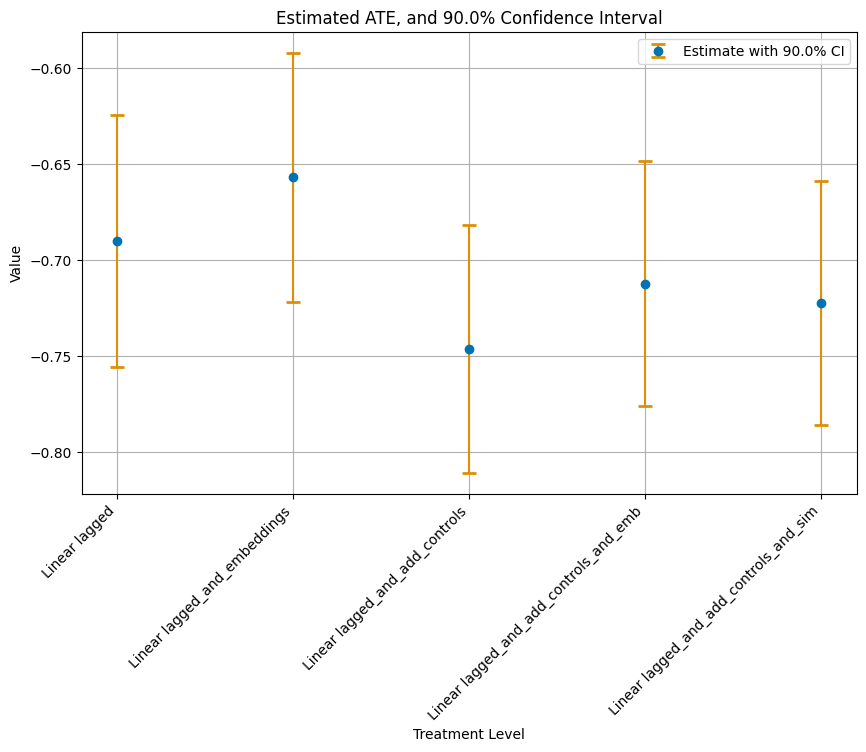

In [28]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_base["model"],
    df_base["coef"],
    yerr=[df_base["coef"] - df_base["lower"], df_base["upper"] - df_base["coef"]],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"linear_ate_estimates.png"))
plt.show()

In [29]:
df_base

,lower,upper,coef,model
0,-0.756093,-0.624438,-0.690266,Linear lagged
1,-0.721957,-0.591964,-0.656960,Linear lagged_and_embeddings
2,-0.811127,-0.681600,-0.746364,Linear lagged_and_add_controls
3,-0.776161,-0.648547,-0.712354,Linear lagged_and_add_controls_and_emb
4,-0.786005,-0.659069,-0.722537,Linear lagged_and_add_controls_and_sim


### DML Models

In [30]:
ml_g = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)
ml_m = LGBMRegressor(n_estimators=500, lr=0.02, random_state=42, verbose=-1)


def r2(y_true, y_pred):
    subset = np.logical_not(np.isnan(y_true))
    return r2_score(y_true[subset], y_pred[subset])


def estimate_dml_model(controls):
    tab_dml_data = dml.DoubleMLClusterData(
        df_dynamic,
        y_col=outcome[0],
        d_cols=base_treatment,
        x_cols=controls,
        cluster_cols="ASIN",
    )

    np.random.seed(3141)
    tab_dml_obj = dml.DoubleMLPLR(tab_dml_data, ml_g, ml_m)
    tab_dml_obj.fit()

    tab_summary_df = summarize_dml(tab_dml_obj, level=confidence_level)
    ci_tab_dml = tab_summary_df[ci_names + ["coef"]]
    ci_tab_dml.columns = ["lower", "upper", "coef"]

    r2_scores = tab_dml_obj.evaluate_learners(metric=r2)
    print(
        f"R2 Outcome: {round(r2_scores['ml_l'][0, 0], 4)} R2 Treatment: {round(r2_scores['ml_m'][0, 0], 4)}\n"
    )

    return tab_dml_obj, ci_tab_dml

In [31]:
tab_dml_obj_embeddings, ci_tab_dml_embeddings = estimate_dml_model(
    controls=lag_1_vars + embeddings
)

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.623    0.049 -12.632    0.0 -0.704 -0.542
R2 Outcome: 0.8636 R2 Treatment: 0.9731



In [32]:
tab_dml_obj_add_controls, ci_tab_dml_add_controls = estimate_dml_model(
    controls=lag_1_vars + additional_controls
)

        coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.69    0.041 -16.812    0.0 -0.758 -0.623
R2 Outcome: 0.8991 R2 Treatment: 0.9775



In [33]:
tab_dml_obj_embeddings_add_controls, ci_tab_dml_embeddings_add_controls = (
    estimate_dml_model(controls=lag_1_vars + embeddings + additional_controls)
)

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.697    0.049 -14.362    0.0 -0.777 -0.617
R2 Outcome: 0.891 R2 Treatment: 0.9744



In [34]:
tab_dml_obj_sim_add_controls, ci_tab_dml_sim_add_controls = estimate_dml_model(
    controls=lag_1_vars + controls_similarities + additional_controls
)

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.691    0.041 -17.051    0.0 -0.757 -0.624
R2 Outcome: 0.9009 R2 Treatment: 0.9774



In [35]:
tab_dml_obj_pca_add_controls, ci_tab_dml_pca_add_controls = estimate_dml_model(
    controls=lag_1_vars + controls_pca + additional_controls
)

         coef  std err       t  P>|t|   5.0%  95.0%
P_bb_t -0.677    0.044 -15.416    0.0 -0.749 -0.605
R2 Outcome: 0.8987 R2 Treatment: 0.9768



### Visualization

In [36]:
ci_tab_dml_embeddings["model"] = "plr_embeddings"
ci_tab_dml_add_controls["model"] = "plr_add_controls"
ci_tab_dml_embeddings_add_controls["model"] = "plr_embeddings_add_controls"
ci_tab_dml_sim_add_controls["model"] = "plr_sim_add_controls"
ci_tab_dml_pca_add_controls["model"] = "plr_pca_add_controls"


df_averages = pd.concat(
    [
        ci_tab_dml_embeddings,
        ci_tab_dml_add_controls,
        ci_tab_dml_embeddings_add_controls,
        ci_tab_dml_sim_add_controls,
        ci_tab_dml_pca_add_controls,
    ],
    ignore_index=True,
)

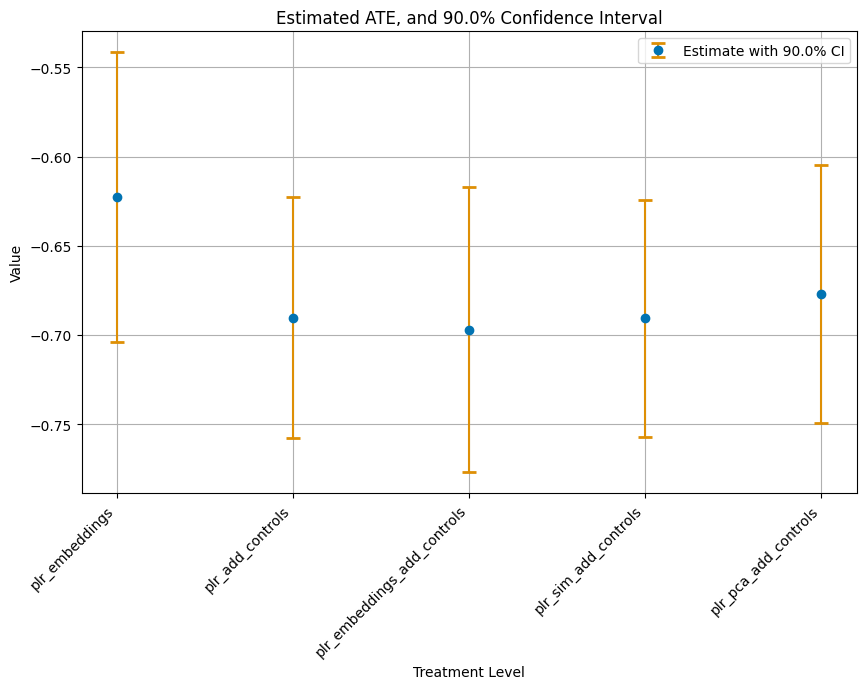

In [37]:
# Plotting
plt.figure(figsize=(10, 6))
# Plot Estimate with CI
plt.errorbar(
    df_averages["model"],
    df_averages["coef"],
    yerr=[
        df_averages["coef"] - df_averages["lower"],
        df_averages["upper"] - df_averages["coef"],
    ],
    fmt="o",
    capsize=5,
    capthick=2,
    ecolor=palette[1],
    color=palette[0],
    label=f"Estimate with {round(confidence_level * 100, 1)}% CI",
    zorder=2,
)

plt.title(f"Estimated ATE, and {round(confidence_level * 100, 1)}% Confidence Interval")
plt.xlabel("Treatment Level")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_dir, f"plr_ate_estimates.png"))
plt.show()

## GATEs

0
similarity_cluster_0    6942
similarity_cluster_1    9966
similarity_cluster_2    8285
similarity_cluster_3    8701
similarity_cluster_4    4147
dtype: int64


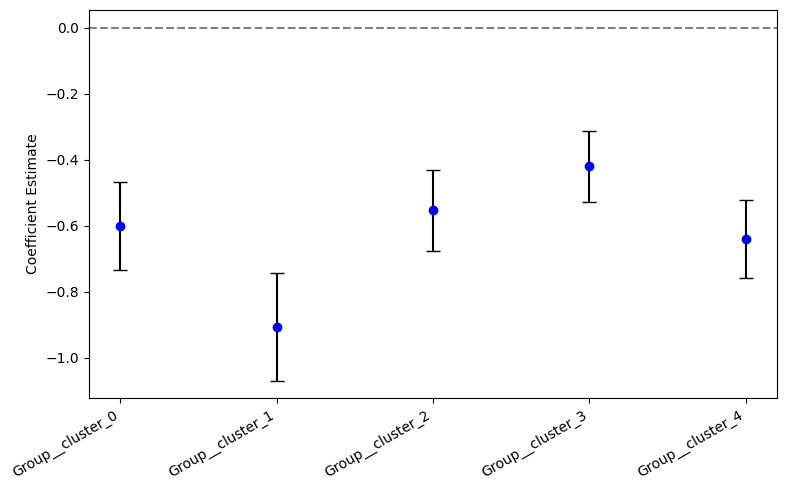

In [38]:
groups = pd.DataFrame(
    df_dynamic[
        [
            "similarity_cluster_0",
            "similarity_cluster_1",
            "similarity_cluster_2",
            "similarity_cluster_3",
            "similarity_cluster_4",
        ]
    ].idxmax(axis=1)
)

print(groups.groupby(0).size())
gates_0 = tab_dml_obj_embeddings.gate(groups)
gates_0_summ = gates_0.summary
gates_0_summ["err_lower"] = gates_0_summ["coef"] - gates_0_summ["[0.025"]
gates_0_summ["err_upper"] = gates_0_summ["0.975]"] - gates_0_summ["coef"]

# Positions on the x-axis
x_vals = range(len(gates_0_summ))

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=x_vals,
    y=gates_0_summ["coef"],
    yerr=[gates_0_summ["err_lower"], gates_0_summ["err_upper"]],
    fmt="o",
    capsize=5,
    color="blue",
    ecolor="black",
)

# Draw a zero line for reference
plt.axhline(y=0, color="gray", linestyle="--")

# Customizing x-axis labels
plt.xticks(
    ticks=x_vals,
    labels=[gr.replace("similarity", "") for gr in gates_0_summ.index],
    rotation=30,
    ha="right",
)
plt.ylabel("Coefficient Estimate")
plt.tight_layout()
plt.show()

## CATEs

In [39]:
uniform_ci = True  # False | True

In [40]:
cate_controls = lag_1_vars + embeddings + additional_controls
cate_controls_interactions = cate_controls + interaction_vars

plr_obj = tab_dml_obj_embeddings_add_controls

In [41]:
cate_kwargs_val = {"cov_type": "cluster", "cov_kwds": {"groups": df_dynamic["ASIN"]}}

cate_models_polynomial = {
    "Linear Specification": None,
    "Linear Specification (Interactions)": None,
    "PLR Specification": None,
}

# Linear Models
cate_models_polynomial["Linear Specification"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls,
    **cate_kwargs_val,
)

print(f"\nLinear Specification")
df_specification_1 = summarize_lin_model(
    cate_models_polynomial["Linear Specification"], level=confidence_level
)
print("=" * 80)  #

cate_models_polynomial["Linear Specification (Interactions)"] = lin_model_cate(
    df=df_dynamic,
    outcome=outcome,
    basis=df_basis,
    treatment=base_treatment,
    controls=cate_controls_interactions,
    **cate_kwargs_val,
)

print(f"\nLinear specification with interactions")
df_specification_2 = summarize_lin_model(
    cate_models_polynomial["Linear Specification (Interactions)"],
    level=confidence_level,
)
print("=" * 80)

# tabular DML model
cate_models_polynomial["PLR Specification"] = plr_obj.cate(df_basis, **cate_kwargs_val)

print(f"\nTabular DML PLR Specification")
df_specification_3 = summarize_lin_model(
    cate_models_polynomial["PLR Specification"].blp_model, level=confidence_level
)
print("=" * 80)


Linear Specification
                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.693    0.039 -17.805  0.000  -0.757 -0.629
Q_t-1                -0.165    0.055  -2.986  0.003  -0.256 -0.074
P_bb_t-1             -0.014    0.050  -0.285  0.776  -0.097  0.068
similarity_cluster_0 -0.139    1.546  -0.090  0.928  -2.683  2.404
similarity_cluster_1 -2.881    1.653  -1.743  0.081  -5.600 -0.162
similarity_cluster_2 -3.595    3.052  -1.178  0.239  -8.615  1.426
similarity_cluster_3 -4.459    3.395  -1.314  0.189 -10.044  1.125
similarity_cluster_4 -2.245    1.112  -2.019  0.044  -4.074 -0.416

Linear specification with interactions
                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.703    0.039 -18.006  0.000  -0.768 -0.639
Q_t-1                -0.186    0.055  -3.362  0.001  -0.278 -0.095
P_bb_t-1             -0.025    0.051  -0.490  0.624  -0.110  0.059
similarity_cluster_0  0.134    1.554   0.086  0.931  -2.423  2.691


In [42]:
cate_models_polynomial["Linear Specification (Interactions)"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):              0.025
Method:                 Least Squares   F-statistic:                              51.12
Date:                Sat, 24 Jan 2026   Prob (F-statistic):                    6.02e-79
Time:                        10:06:54   Log-Likelihood:                         -20981.
No. Observations:               38041   AIC:                                  4.198e+04
Df Residuals:                   38033   BIC:                                  4.205e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.7033      0.039    -18.006      0.000      -0.780      -0.627
Q_t-1                   -0.1865      0.055     -3.362      0.001      -0.295      -0.078
P_bb_t-1                -0.0251      0.051     -0.490      0.624      -0.126       0.075
similarity_cluster_0     0.1337      1.554      0.086      0.931      -2.913       3.180
similarity_cluster_1    -2.6552      1.682     -1.579      0.114      -5.951       0.641
similarity_cluster_2    -3.8265      3.060     -1.250      0.211      -9.824       2.171
similarity_cluster_3    -4.6717      3.405     -1.372      0.170     -11.346       2.003
similarity_cluster_4    -2.2135      1.126     -1.965      0.049      -4.421      -0.006
==============================================================================
Omnibus:                    12065.225   Durbin-Watson:                   1.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           704593.441
Skew:                           0.713   Prob(JB):                         0.00
Kurtosis:                      24.036   Cond. No.                         174.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [43]:
cate_models_polynomial["PLR Specification"].blp_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):              0.032
Method:                 Least Squares   F-statistic:                              45.90
Date:                Sat, 24 Jan 2026   Prob (F-statistic):                    7.31e-71
Time:                        10:06:54   Log-Likelihood:                         -21680.
No. Observations:               38041   AIC:                                  4.338e+04
Df Residuals:                   38033   BIC:                                  4.345e+04
Df Model:                           8                                                  
Covariance Type:              cluster                                                  
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept               -0.7358      0.046    -15.860      0.000      -0.827      -0.645
Q_t-1                   -0.3248      0.092     -3.515      0.000      -0.506      -0.144
P_bb_t-1                -0.0488      0.035     -1.401      0.161      -0.117       0.019
similarity_cluster_0    -2.3123      1.524     -1.517      0.129      -5.300       0.675
similarity_cluster_1    -7.3655      1.831     -4.023      0.000     -10.954      -3.777
similarity_cluster_2    -6.7850      3.558     -1.907      0.056     -13.758       0.188
similarity_cluster_3    -8.2553      3.985     -2.072      0.038     -16.066      -0.445
similarity_cluster_4    -4.5594      1.303     -3.500      0.000      -7.113      -2.006
==============================================================================
Omnibus:                    14871.916   Durbin-Watson:                   1.543
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           527409.889
Skew:                           1.221   Prob(JB):                         0.00
Kurtosis:                      21.077   Cond. No.                         296.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors are robust to cluster correlation (cluster)
"""

In [44]:
latex_args = {
    "index": True,
    "float_format": "%.3f",
    "column_format": "lcccccc",
}

print(df_specification_1.to_latex(**latex_args))
print(df_specification_2.to_latex(**latex_args))
print(df_specification_3.to_latex(**latex_args))

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.693 & 0.039 & -17.805 & 0.000 & -0.757 & -0.629 \\
Q_t-1 & -0.165 & 0.055 & -2.986 & 0.003 & -0.256 & -0.074 \\
P_bb_t-1 & -0.014 & 0.050 & -0.285 & 0.776 & -0.097 & 0.068 \\
similarity_cluster_0 & -0.139 & 1.546 & -0.090 & 0.928 & -2.683 & 2.404 \\
similarity_cluster_1 & -2.881 & 1.653 & -1.743 & 0.081 & -5.600 & -0.162 \\
similarity_cluster_2 & -3.595 & 3.052 & -1.178 & 0.239 & -8.615 & 1.426 \\
similarity_cluster_3 & -4.459 & 3.395 & -1.314 & 0.189 & -10.044 & 1.125 \\
similarity_cluster_4 & -2.245 & 1.112 & -2.019 & 0.044 & -4.074 & -0.416 \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccccc}
\toprule
 & coef & std err & t & P>|t| & 5.0% & 95.0% \\
\midrule
intercept & -0.703 & 0.039 & -18.006 & 0.000 & -0.768 & -0.639 \\
Q_t-1 & -0.186 & 0.055 & -3.362 & 0.001 & -0.278 & -0.095 \\
P_bb_t-1 & -0.025 & 0.051 & -0.490 & 0.624 & -0.110 & 0.059 \\
similarity_cluster_0 & 0.134 & 1.

In [45]:
summary_list = []
for model_name, model in cate_models_polynomial.items():
    if "Linear" in model_name:
        tmp_summary = summarize_lin_model(model, level=confidence_level)
    else:
        tmp_summary = summarize_lin_model(model.blp_model, level=confidence_level)
    for index, row in tmp_summary.iterrows():
        variable = index
        summary_list.append(
            {
                "model": model_name,
                "variable": variable,
                "coef": row["coef"],
                "Std.Err.": row["std err"],
                "lower": row[ci_names[0]],  # Adjusted to match the column name
                "upper": row[ci_names[1]],  # Adjusted to match the column name
            }
        )

cate_summary_df = pd.DataFrame(summary_list)

                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.693    0.039 -17.805  0.000  -0.757 -0.629
Q_t-1                -0.165    0.055  -2.986  0.003  -0.256 -0.074
P_bb_t-1             -0.014    0.050  -0.285  0.776  -0.097  0.068
similarity_cluster_0 -0.139    1.546  -0.090  0.928  -2.683  2.404
similarity_cluster_1 -2.881    1.653  -1.743  0.081  -5.600 -0.162
similarity_cluster_2 -3.595    3.052  -1.178  0.239  -8.615  1.426
similarity_cluster_3 -4.459    3.395  -1.314  0.189 -10.044  1.125
similarity_cluster_4 -2.245    1.112  -2.019  0.044  -4.074 -0.416
                       coef  std err       t  P>|t|    5.0%  95.0%
intercept            -0.703    0.039 -18.006  0.000  -0.768 -0.639
Q_t-1                -0.186    0.055  -3.362  0.001  -0.278 -0.095
P_bb_t-1             -0.025    0.051  -0.490  0.624  -0.110  0.059
similarity_cluster_0  0.134    1.554   0.086  0.931  -2.423  2.691
similarity_cluster_1 -2.655    1.682  -1.579  0.114  -5.421  0

In [46]:
cate_summary_df

,model,variable,coef,Std.Err.,lower,upper
0,Linear Specification,intercept,-0.692672,0.038904,-0.756664,-0.628680
1,Linear Specification,Q_t-1,-0.165293,0.055356,-0.256346,-0.074241
2,Linear Specification,P_bb_t-1,-0.014324,0.050290,-0.097043,0.068396
3,Linear Specification,similarity_cluster_0,-0.139450,1.546406,-2.683062,2.404161
4,Linear Specification,similarity_cluster_1,-2.881275,1.653033,-5.600272,-0.162278
5,Linear Specification,similarity_cluster_2,-3.594823,3.052160,-8.615179,1.425533
6,Linear Specification,similarity_cluster_3,-4.459442,3.395056,-10.043812,1.124928
7,Linear Specification,similarity_cluster_4,-2.244834,1.111967,-4.073857,-0.415811
8,Linear Specification (Interactions),intercept,-0.703280,0.039058,-0.767525,-0.639035
9,Linear Specification (Interactions),Q_t-1,-0.186490,0.055462,-0.277717,-0.095262


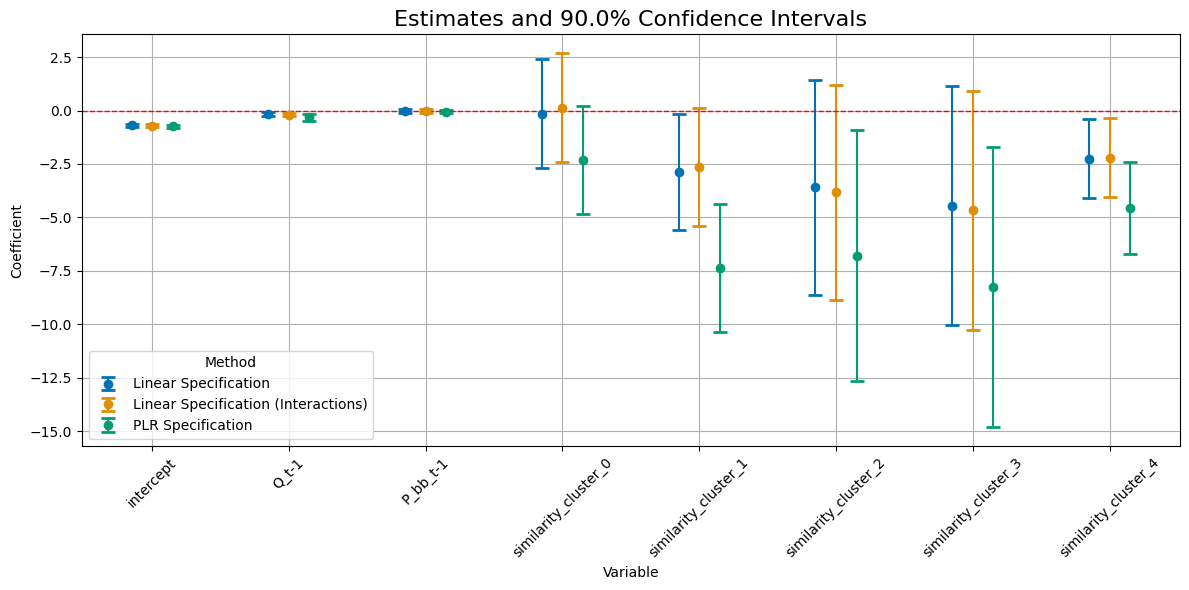

In [47]:
models = cate_summary_df["model"].unique()
variables = cate_summary_df["variable"].unique()
plt.figure(figsize=(12, 6))
bar_width = 0.15
x_positions = np.arange(len(variables))
for i, model in enumerate(models):
    df_model = cate_summary_df[cate_summary_df["model"] == model]
    if not df_model.empty:
        plt.errorbar(
            x_positions + i * bar_width,
            df_model["coef"],
            yerr=[
                df_model["coef"] - df_model["lower"],
                df_model["upper"] - df_model["coef"],
            ],
            fmt="o",
            label=model,
            capsize=5,
            capthick=2,
            ecolor=palette[i % len(palette)],
            color=palette[i % len(palette)],
            zorder=2,
        )
plt.xticks(x_positions + (len(models) - 1) * bar_width / 2, variables, rotation=45)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Estimates and {ci_level_name} Confidence Intervals", fontsize=16)
plt.xlabel("Variable")
plt.ylabel("Coefficient")
plt.legend(title="Method")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"cluster_and_level_cate_estimates.png"))
plt.show()

### $R^2$

In [48]:
alpha_x_lin = cate_models_polynomial["Linear Specification"].predict(df_basis)
alpha_x_lin_interactions = cate_models_polynomial[
    "Linear Specification (Interactions)"
].predict(df_basis)
alpha_x_plr = cate_models_polynomial["PLR Specification"].blp_model.predict(df_basis)


print("Linear Specification")
model_lin_emb = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[embeddings])).fit()
model_lin_sim = sm.OLS(
    alpha_x_lin, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_lin_lvl = sm.OLS(alpha_x_lin, sm.add_constant(df_dynamic[lag_1_vars])).fit()

print("Variance explained by embeddings: ", model_lin_emb.rsquared)
print("Variance explained by similarities: ", model_lin_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_lvl.rsquared)

print("Linear Specification with interactions")
model_lin_interactions_emb = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[embeddings])
).fit()
model_lin_interactions_sim = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_lin_interactions_lvl = sm.OLS(
    alpha_x_lin_interactions, sm.add_constant(df_dynamic[lag_1_vars])
).fit()
print("Variance explained by embeddings: ", model_lin_interactions_emb.rsquared)
print("Variance explained by similarities: ", model_lin_interactions_sim.rsquared)
print("Variance explained by lagged variables: ", model_lin_interactions_lvl.rsquared)

print("PLR Specification")
model_plr_emb = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[embeddings])).fit()
model_plr_sim = sm.OLS(
    alpha_x_plr, sm.add_constant(df_dynamic[controls_similarities])
).fit()
model_plr_lvl = sm.OLS(alpha_x_plr, sm.add_constant(df_dynamic[lag_1_vars])).fit()
print("Variance explained by embeddings: ", model_plr_emb.rsquared)
print("Variance explained by similarities: ", model_plr_sim.rsquared)
print("Variance explained by lagged variables: ", model_plr_lvl.rsquared)

Linear Specification
Variance explained by embeddings:  0.7283031151761112
Variance explained by similarities:  0.6782509504700582
Variance explained by lagged variables:  0.7396255824888652
Linear Specification with interactions
Variance explained by embeddings:  0.6861223063315358
Variance explained by similarities:  0.6279801110205161
Variance explained by lagged variables:  0.7753125921658433
PLR Specification
Variance explained by embeddings:  0.5835124047901281
Variance explained by similarities:  0.5062094657968086
Variance explained by lagged variables:  0.7468357881193537


## $\Chi^2$ Test

In [49]:
# select index with cluster similarity
cluster_treatment_ids = [
    i for i, variable in enumerate(df_basis.columns) if "similarity_cluster" in variable
]
cluster_treatment_ids

[3, 4, 5, 6, 7]

In [50]:
lin_p_val = chi2_test(
    cate_models_polynomial["Linear Specification"], cluster_treatment_ids
)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], cluster_treatment_ids
)
tab_dml_p_val = chi2_test(
    cate_models_polynomial["PLR Specification"], cluster_treatment_ids
)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(
    f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})"
)
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 0.029984178246319604 (sample size: 38041)
Linear Specification (Interactions) p-value: 0.0538828559164648 (sample size: 38041)
PLR Specification p-value: 0.0009061660603711941 (sample size: 38041)


In [51]:
het_ids = [1, 2, 3, 4, 5, 6, 7]

lin_p_val = chi2_test(cate_models_polynomial["Linear Specification"], het_ids)
lin_interactions_p_val = chi2_test(
    cate_models_polynomial["Linear Specification (Interactions)"], het_ids
)
tab_dml_p_val = chi2_test(cate_models_polynomial["PLR Specification"], het_ids)

print(f"Linear Specification p-value: {lin_p_val} (sample size: {len(df_dynamic)})")
print(
    f"Linear Specification (Interactions) p-value: {lin_interactions_p_val} (sample size: {len(df_dynamic)})"
)
print(f"PLR Specification p-value: {tab_dml_p_val} (sample size: {len(df_dynamic)})")

Linear Specification p-value: 5.046780121920058e-06 (sample size: 38041)
Linear Specification (Interactions) p-value: 3.7771242907824742e-06 (sample size: 38041)
PLR Specification p-value: 4.3235888869119776e-08 (sample size: 38041)


## Sorted Effects

In [52]:
treatment_ids = [0, 1, 2] + cluster_treatment_ids
df_basis_sorted = df_basis.iloc[:, treatment_ids]  # .join(df_dynamic[["ASIN", "date"]])

In [53]:
df_basis_sorted

,intercept,Q_t-1,P_bb_t-1,similarity_cluster_0,similarity_cluster_1,similarity_cluster_2,similarity_cluster_3,similarity_cluster_4
0,1.0,0.305280,0.463601,-0.461880,0.463422,0.457113,-0.620049,-0.080700
1,1.0,0.272505,0.653600,-0.461880,0.463422,0.457113,-0.620049,-0.080700
2,1.0,0.036240,0.687961,-0.461695,0.459950,0.457477,-0.622177,-0.072107
3,1.0,0.025283,0.636881,-0.461695,0.459950,0.457477,-0.622177,-0.072107
4,1.0,-0.051370,0.556816,-0.461695,0.459950,0.457477,-0.622177,-0.072107
...,...,...,...,...,...,...,...,...
38036,1.0,0.009068,0.478593,-0.079348,0.162986,0.069090,-0.088975,-0.156031
38037,1.0,-0.393270,-0.753352,0.395061,-0.460362,0.706488,-0.570121,0.486352
38038,1.0,-0.277916,-0.753352,0.381826,-0.444585,0.722214,-0.589989,0.487661
38039,1.0,1.267533,-1.535804,-0.386963,0.324396,0.753702,-0.877618,0.092195


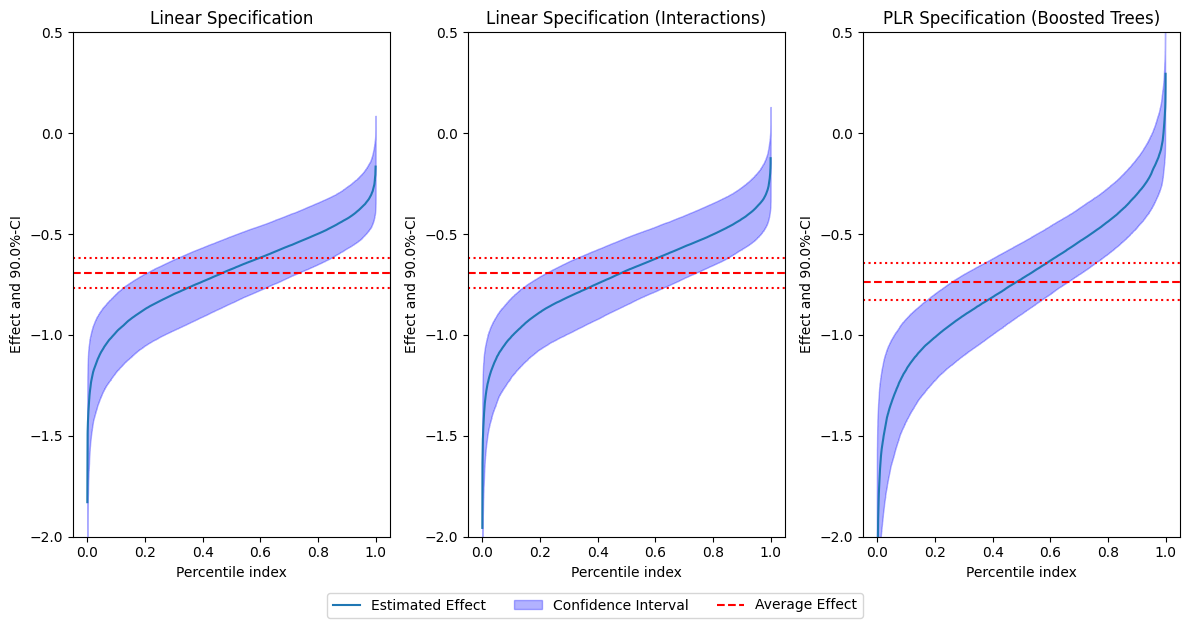

In [54]:
uniform_ci = False

plt.rcParams["figure.figsize"] = (
    15.0,
    7.5,
)  # Adjusted the figure size for side-by-side plots
# Determine the number of models to plot
num_plots = 1
# Create subplots with cate_vars as rows and models as columns
fig, axs = plt.subplots(nrows=num_plots, ncols=3, figsize=(12, 6 * num_plots))
# If there's only one model, axs won't be a list, so wrap it in a list
if num_plots == 1:
    axs = np.array([axs, axs])  # Create a 2-column array


# Linear model
df_lin_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_lin_ci_pointwise_sorted = df_lin_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_lin_ci_uniform = predict_cate(
    cate_models_polynomial["Linear Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_lin_ci_uniform_sorted = df_lin_ci_uniform.apply(
    lambda x: x.sort_values().values, axis=0
)
lm_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
lm_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# Tabular DML model
df_tab_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_tab_dml_ci_pointwise_sorted = df_tab_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_tab_dml_ci_joint = predict_cate(
    cate_models_polynomial["Linear Specification (Interactions)"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_tab_dml_ci_joint_sorted = df_tab_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)

tab_dml_intercept = cate_models_polynomial["Linear Specification"].params["intercept"]
tab_dml_intercept_ci = (
    cate_models_polynomial["Linear Specification"].conf_int().loc["intercept"]
)

# PLR Model
df_deep_dml_ci_pointwise = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
)
df_deep_dml_ci_pointwise_sorted = df_deep_dml_ci_pointwise.apply(
    lambda x: x.sort_values().values, axis=0
)
df_deep_dml_ci_joint = predict_cate(
    cate_models_polynomial["PLR Specification"],
    df_basis_sorted,
    treatment_ids=treatment_ids,
    level=confidence_level,
    joint=True,
)
df_deep_dml_ci_joint_sorted = df_deep_dml_ci_joint.apply(
    lambda x: x.sort_values().values, axis=0
)
deep_dml_intercept = cate_models_polynomial["PLR Specification"].blp_model.params[
    "intercept"
]
deep_dml_intercept_ci = (
    cate_models_polynomial["PLR Specification"].blp_model.conf_int().loc["intercept"]
)

# Calculate the y-axis limits for this row
y_min = min(
    df_lin_ci_pointwise[ci_names[0]].min(),
    df_lin_ci_uniform[ci_names[0]].min(),
    df_tab_dml_ci_pointwise[ci_names[0]].min(),
    df_tab_dml_ci_joint[ci_names[0]].min(),
    df_deep_dml_ci_pointwise[ci_names[0]].min(),
    df_deep_dml_ci_joint[ci_names[0]].min(),
)
y_max = max(
    df_lin_ci_pointwise[ci_names[1]].max(),
    df_lin_ci_uniform[ci_names[1]].max(),
    df_tab_dml_ci_pointwise[ci_names[1]].max(),
    df_tab_dml_ci_joint[ci_names[1]].max(),
    df_deep_dml_ci_pointwise[ci_names[1]].max(),
    df_deep_dml_ci_joint[ci_names[1]].max(),
)

# further adjust y-axis limits
y_min = max(y_min, -2)
y_max = min(y_max, 0.5)
percentiles_idx = np.linspace(0, 1, df_dynamic.shape[0])
percentiles_idx_full = np.linspace(0, 1, df_dynamic.shape[0])
# Plot on the first column
i = 0
ax0 = axs[i, 0]
ax0.plot(
    percentiles_idx_full, df_lin_ci_pointwise_sorted["effect"], label="Estimated Effect"
)
ax0.fill_between(
    percentiles_idx_full,
    df_lin_ci_pointwise_sorted[ci_names[0]],
    df_lin_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax0.fill_between(
        percentiles_idx_full,
        df_lin_ci_uniform_sorted[ci_names[0]],
        df_lin_ci_uniform_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax0.axhline(y=lm_intercept, color="r", linestyle="--", label="ATE")
ax0.axhline(y=lm_intercept_ci[0], color="r", linestyle="dotted")
ax0.axhline(y=lm_intercept_ci[1], color="r", linestyle="dotted")
ax0.set_title("Linear Specification")
ax0.set_xlabel("Percentile index")
ax0.set_ylabel(f"Effect and {ci_level_name}-CI")
ax0.set_ylim(y_min, y_max)
ax1 = axs[i, 1]
ax1.plot(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax1.fill_between(
    percentiles_idx_full,
    df_tab_dml_ci_pointwise_sorted[ci_names[0]],
    df_tab_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax1.fill_between(
        percentiles_idx_full,
        df_tab_dml_ci_joint_sorted[ci_names[0]],
        df_tab_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax1.axhline(y=tab_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax1.axhline(y=tab_dml_intercept_ci[0], color="r", linestyle="dotted")
ax1.axhline(y=tab_dml_intercept_ci[1], color="r", linestyle="dotted")
ax1.set_title("Linear Specification (Interactions)")
ax1.set_xlabel("Percentile index")
ax1.set_ylabel(f"Effect and {ci_level_name}-CI")
ax1.set_ylim(y_min, y_max)

ax2 = axs[i, 2]
ax2.plot(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted["effect"],
    label="Estimated Effect",
)
ax2.fill_between(
    percentiles_idx_full,
    df_deep_dml_ci_pointwise_sorted[ci_names[0]],
    df_deep_dml_ci_pointwise_sorted[ci_names[1]],
    color="b",
    alpha=0.3,
    label="Confidence Interval",
)
if uniform_ci:
    ax2.fill_between(
        percentiles_idx_full,
        df_deep_dml_ci_joint_sorted[ci_names[0]],
        df_deep_dml_ci_joint_sorted[ci_names[1]],
        color="b",
        alpha=0.1,
        label="Uniform Confidence Interval",
    )
ax2.axhline(y=deep_dml_intercept, color="r", linestyle="--", label="Average Effect")
ax2.axhline(y=deep_dml_intercept_ci[0], color="r", linestyle="dotted")
ax2.axhline(y=deep_dml_intercept_ci[1], color="r", linestyle="dotted")

ax2.set_title("PLR Specification (Boosted Trees)")
ax2.set_xlabel("Percentile index")
ax2.set_ylabel(f"Effect and {ci_level_name}-CI")
ax2.set_ylim(y_min, y_max)

# Create a single legend for all plots and place it at the lower center
handles, labels = axs[
    -1, 1 
].get_legend_handles_labels()  # Collect handles and labels from the last subplot
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=4)
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.0, 1, 1])  # Leave space at the bottom for the legend

# Save the figure with tight bounding box to include the legend
plt.savefig(os.path.join(output_dir, "cluster_sorted_effects.png"), bbox_inches="tight")
plt.show()

In [55]:
quantiles = np.arange(start=0.01, stop=1, step=0.01)
m = len(quantiles)
pes = df_tab_dml_ci_pointwise["effect"]
spes = df_tab_dml_ci_pointwise["effect"].quantile(quantiles).values
spes

array([-1.32198408, -1.23329557, -1.18107363, -1.14354946, -1.11162049,
       -1.08522233, -1.06420504, -1.04394366, -1.02580337, -1.010058  ,
       -0.99492252, -0.9809761 , -0.96792875, -0.95406243, -0.94057512,
       -0.92905576, -0.91823026, -0.90750734, -0.8977652 , -0.88753871,
       -0.87758667, -0.86897235, -0.86121569, -0.85330791, -0.84592225,
       -0.83842537, -0.83196603, -0.82447797, -0.81769153, -0.81052953,
       -0.80418167, -0.79749779, -0.79125086, -0.78497899, -0.77833915,
       -0.77198144, -0.76559575, -0.75877775, -0.75193425, -0.74561754,
       -0.73924165, -0.73294451, -0.72633099, -0.72032155, -0.71418683,
       -0.70691883, -0.70074403, -0.69422087, -0.6879893 , -0.68128868,
       -0.67500074, -0.66946448, -0.66334161, -0.65798933, -0.65221556,
       -0.64645205, -0.6404376 , -0.63490947, -0.62878975, -0.62294119,
       -0.6172833 , -0.61122978, -0.60546322, -0.59920371, -0.59288032,
       -0.58729722, -0.58142857, -0.57540835, -0.56929716, -0.56

# Sensitivity Analysis

Sensitivity analysis for ATE with PLM model.

In [56]:
plr_obj.sensitivity_analysis(
    cf_y=0.03,
    cf_d=0.03,
    rho=1.0,
    level=0.9,
    null_hypothesis=0.0
)
print(plr_obj.sensitivity_summary)

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.9
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
        CI lower  theta lower     theta  theta upper  CI upper
P_bb_t -0.889641    -0.829018 -0.697126    -0.565233 -0.500973

------------------ Robustness Values ------------------
        H_0     RV (%)    RVa (%)
P_bb_t  0.0  14.856088  13.366702


In [57]:
sensitivity_res = dict()

rho_vec = [1.0, 0.5, 0.2]
scenarios = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]

theta_lower = []
theta_upper = []
ci_lower = []
ci_upper = []
R2_y = []
R2_d = []
rho_list = []

for rho in rho_vec:
    for cf_y, cf_d in scenarios:
        plr_obj.sensitivity_analysis(
            cf_y=cf_y,
            cf_d=cf_d,
            rho=rho,
            level=confidence_level,
            null_hypothesis=0.0
        )
        theta_lower.append(plr_obj.sensitivity_params["theta"]["lower"][0])
        theta_upper.append(plr_obj.sensitivity_params["theta"]["upper"][0])
        ci_lower.append(plr_obj.sensitivity_params["ci"]["lower"][0])
        ci_upper.append(plr_obj.sensitivity_params["ci"]["upper"][0])
        R2_y.append(cf_y)
        R2_d.append(cf_d)
        rho_list.append(rho)


In [58]:
df_sensitivity = pd.DataFrame({
    "theta": plr_obj.coef[0],
    "theta_lower": theta_lower,
    "theta_upper": theta_upper,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper,
    "R2_y": R2_y,
    "R2_d": R2_d,
    "rho": rho_list,
})
df_sensitivity.head()

,theta,theta_lower,theta_upper,ci_lower,ci_upper,R2_y,R2_d,rho
0,-0.697126,-0.740644,-0.653608,-0.802271,-0.590776,0.010,0.010,1.0
1,-0.697126,-0.806754,-0.587498,-0.867608,-0.523616,0.025,0.025,1.0
2,-0.697126,-0.919249,-0.475003,-0.979082,-0.409086,0.050,0.050,1.0
3,-0.697126,-0.718885,-0.675367,-0.780794,-0.612855,0.010,0.010,0.5
4,-0.697126,-0.751940,-0.642312,-0.813427,-0.579308,0.025,0.025,0.5


In [59]:
scenario_names = ["mild", "medium", "strong"]

latex_args = {
    "index": False,
    "float_format": "%.3f",
    "column_format": "lcccccc",
    "escape": False,  # Allow LaTeX in column names
}

ci_lower_label = f"$[ {{{100*(1-confidence_level):.1f}}}\\% $"
ci_upper_label = f"${{{100*(confidence_level):.1f}}}\\% ]$"

for rho_val in rho_vec:
    df_rho = df_sensitivity[df_sensitivity["rho"] == rho_val].copy()
    # Add scenario column with names
    df_rho["Scenario ($R^2_Y$, $R^2_D$)"] = [
        f"{name} $({str(r2y).lstrip('0')}, {str(r2d).lstrip('0')})$"
        for name, r2y, r2d in zip(scenario_names, df_rho["R2_y"], df_rho["R2_d"])
    ]
    # Rename columns for LaTeX
    df_rho = df_rho.rename(
        columns={
            "theta": r"$\theta$",
            "theta_lower": r"$\theta_-$",
            "theta_upper": r"$\theta_+$",
            "ci_lower": ci_lower_label,
            "ci_upper": ci_upper_label,
        }
    )
    # Reorder columns as requested
    df_rho = df_rho[
        [
            "Scenario ($R^2_Y$, $R^2_D$)",
            ci_lower_label,
            r"$\theta_-$",
            r"$\theta$",
            r"$\theta_+$",
            ci_upper_label,
        ]
    ]
    caption = (
        f"Sensitivity analysis for $\\rho={rho_val}$: "
    )
    latex_str = df_rho.to_latex(
        caption=caption,
        label=f"tab:sensitivity_rho_{str(rho_val).replace('.', '')}",
        **latex_args,
    )
    # Insert \hline\hline after \begin{tabular} and replace \toprule/\bottomrule
    latex_str = latex_str.replace("\\toprule", "\\hline\\hline")
    latex_str = latex_str.replace("\\midrule", "\\midrule")
    latex_str = latex_str.replace("\\bottomrule", "\\hline\\hline")
    latex_str = latex_str.replace("\\begin{table}", "\\begin{table}[h]\n\\centering")
    print(latex_str)

\begin{table}[h]
\centering
\caption{Sensitivity analysis for $\rho=1.0$: }
\label{tab:sensitivity_rho_10}
\begin{tabular}{lcccccc}
\hline\hline
Scenario ($R^2_Y$, $R^2_D$) & $[ {10.0}\% $ & $\theta_-$ & $\theta$ & $\theta_+$ & ${90.0}\% ]$ \\
\midrule
mild $(.01, .01)$ & -0.802 & -0.741 & -0.697 & -0.654 & -0.591 \\
medium $(.025, .025)$ & -0.868 & -0.807 & -0.697 & -0.587 & -0.524 \\
strong $(.05, .05)$ & -0.979 & -0.919 & -0.697 & -0.475 & -0.409 \\
\hline\hline
\end{tabular}
\end{table}

\begin{table}[h]
\centering
\caption{Sensitivity analysis for $\rho=0.5$: }
\label{tab:sensitivity_rho_05}
\begin{tabular}{lcccccc}
\hline\hline
Scenario ($R^2_Y$, $R^2_D$) & $[ {10.0}\% $ & $\theta_-$ & $\theta$ & $\theta_+$ & ${90.0}\% ]$ \\
\midrule
mild $(.01, .01)$ & -0.781 & -0.719 & -0.697 & -0.675 & -0.613 \\
medium $(.025, .025)$ & -0.813 & -0.752 & -0.697 & -0.642 & -0.579 \\
strong $(.05, .05)$ & -0.869 & -0.808 & -0.697 & -0.586 & -0.522 \\
\hline\hline
\end{tabular}
\end{table}

\begin